## Import libraries

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [113]:
## The standard metric
def weighted_mean_absolute_error(y_true, y_pred, weights):
    return (weights * np.abs(y_true - y_pred)).mean()

In [114]:
## display setting for plt
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)

## Loading Data

In [115]:
df_train = pd.read_csv("hackathon_income_train.csv", delimiter=";", decimal=',')

C:\Users\emryz\AppData\Local\Temp\ipykernel_11472\2960608455.py:1: DtypeWarning: Columns (66) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv("hackathon_income_train.csv", delimiter=";", decimal=',')


In [116]:
df_test = pd.read_csv("hackathon_income_test.csv", delimiter=";", decimal=',')

C:\Users\emryz\AppData\Local\Temp\ipykernel_11472\2636850932.py:1: DtypeWarning: Columns (65) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv("hackathon_income_test.csv", delimiter=";", decimal=',')


## Exploring the data

In [117]:
## The two features missing are the target and the weight, which i believe is given and should not be included in your training. 
##only necessary for data preprocessing
print(len(df_train.columns))
print(len(df_test.columns)) ## not used

224
222


In [118]:
## lets confirm the missing features
set(df_train.columns) - set(df_test.columns) == {'target', 'w'}

True

In [10]:
df_train.head()

,id,dt,target,turn_cur_cr_avg_act_v2,salary_6to12m_avg,hdb_bki_total_max_limit,dp_ils_paymentssum_avg_12m,hdb_bki_total_cc_max_limit,incomeValue,gender,...,dp_ils_uniq_companies_1y,avg_6m_travel,avg_6m_government_services,hdb_bki_active_cc_max_overdue,total_rur_amt_cm_avg_period_days_ago_v2,label_Above_1M_share_r1,transaction_category_supermarket_sum_cnt_d15,max_balance_rur_amt_1m_af,w,first_salary_income
0,2,2024-04-30,109324.476325,1465144.960,NaN,52800.0,365346.244634,23213.0,97366.0,Женский,...,1.0,0.0,57.0,0.0,297.0,0.027027,9.0,NaN,0.301217,NaN
1,4,2024-02-29,25558.028662,303593.660,NaN,260200.0,NaN,10000.0,32580.0,Женский,...,NaN,0.0,707.0,67.0,30245.0,NaN,2.0,NaN,0.695800,NaN
2,5,2024-02-29,40666.753098,490754.010,NaN,2000000.0,NaN,90000.0,96866.0,Женский,...,NaN,422.0,0.0,0.0,210322.0,0.000000,20.0,NaN,0.515970,NaN
3,6,2024-04-30,43856.672058,219875.120,NaN,75000.0,NaN,75000.0,43860.0,Мужской,...,NaN,0.0,0.0,0.0,7187.0,0.000000,7.0,NaN,0.478003,NaN
4,7,2024-04-30,130420.851992,1750241.845,NaN,1000000.0,NaN,240000.0,83815.0,Женский,...,NaN,0.0,84.0,0.0,690038.0,0.000000,9.0,NaN,0.552314,NaN


### Get numerical and categogorical features

In [122]:
## Numerical features
df_train_numericals = df_train.select_dtypes(include=[np.number])

In [121]:
df_train_numericals.head()

,id,target,turn_cur_cr_avg_act_v2,salary_6to12m_avg,dp_ils_paymentssum_avg_12m,incomeValue,avg_cur_cr_turn,turn_cur_cr_avg_v2,turn_cur_cr_max_v2,age,...,total_sum,dp_ils_uniq_companies_1y,avg_6m_travel,avg_6m_government_services,total_rur_amt_cm_avg_period_days_ago_v2,label_Above_1M_share_r1,transaction_category_supermarket_sum_cnt_d15,max_balance_rur_amt_1m_af,w,first_salary_income
0,2,109324.476325,1465144.960,NaN,365346.244634,97366.0,124649.0,122095.413333,114798.72,40.0,...,0.0,1.0,0.0,57.0,297.0,0.027027,9.0,NaN,0.301217,NaN
1,4,25558.028662,303593.660,NaN,NaN,32580.0,63653.0,75898.415000,260200.00,43.0,...,0.0,NaN,0.0,707.0,30245.0,NaN,2.0,NaN,0.695800,NaN
2,5,40666.753098,490754.010,NaN,NaN,96866.0,404545.0,122688.502500,265000.00,48.0,...,0.0,NaN,422.0,0.0,210322.0,0.000000,20.0,NaN,0.515970,NaN
3,6,43856.672058,219875.120,NaN,NaN,43860.0,39988.0,18322.926667,23000.00,47.0,...,NaN,NaN,0.0,0.0,7187.0,0.000000,7.0,NaN,0.478003,NaN
4,7,130420.851992,1750241.845,NaN,NaN,83815.0,202439.0,291706.974167,415000.00,46.0,...,NaN,NaN,0.0,84.0,690038.0,0.000000,9.0,NaN,0.552314,NaN


In [123]:
## Categorical Features
df_train_categorical = df_train.select_dtypes(include="object")

In [50]:
df_train_categorical.head()

,dt,hdb_bki_total_max_limit,hdb_bki_total_cc_max_limit,gender,adminarea,hdb_bki_total_pil_max_limit,hdb_bki_active_cc_max_limit,city_smart_name,hdb_bki_other_active_pil_outstanding,dp_ewb_last_employment_position,...,hdb_bki_active_pil_cnt,period_last_act_ad,hdb_bki_total_cc_max_overdue,hdb_bki_total_pil_last_days,hdb_bki_active_pil_max_limit,hdb_bki_total_pil_cnt,hdb_bki_total_pil_max_del90,hdb_bki_last_product_days,hdb_bki_other_active_ip_outstanding,hdb_bki_active_cc_max_overdue
0,2024-04-30,52800.0,23213.0,Женский,Свердловская область,52800.0,13000.0,Екатеринбург,NaN,ВРАЧ-ДЕРМАТОВЕНЕРОЛОГ,...,0.0,NaN,0.0,808.0,NaN,2.0,0.0,808.0,NaN,0.0
1,2024-02-29,260200.0,10000.0,Женский,Краснодарский край,260200.0,0.0,Краснодар,NaN,NaN,...,1.0,NaN,67.0,217.0,260200.0,3.0,15.0,217.0,NaN,67.0
2,2024-02-29,2000000.0,90000.0,Женский,Новосибирская область,100000.0,90000.0,Томск,NaN,NaN,...,0.0,NaN,368.0,6061.0,NaN,2.0,0.0,1168.0,709889.375,0.0
3,2024-04-30,75000.0,75000.0,Мужской,Хабаровский край,29760.0,60000.0,Хабаровск,NaN,NaN,...,0.0,NaN,312.0,1544.0,NaN,6.0,0.0,887.0,NaN,0.0
4,2024-04-30,1000000.0,240000.0,Женский,Новосибирская область,1000000.0,240000.0,Новосибирск,124714.828125,NaN,...,1.0,NaN,0.0,1446.0,1000000.0,6.0,0.0,1446.0,NaN,0.0


### Check for Missing values

In [124]:
df_train.describe()

,id,target,turn_cur_cr_avg_act_v2,salary_6to12m_avg,dp_ils_paymentssum_avg_12m,incomeValue,avg_cur_cr_turn,turn_cur_cr_avg_v2,turn_cur_cr_max_v2,age,...,total_sum,dp_ils_uniq_companies_1y,avg_6m_travel,avg_6m_government_services,total_rur_amt_cm_avg_period_days_ago_v2,label_Above_1M_share_r1,transaction_category_supermarket_sum_cnt_d15,max_balance_rur_amt_1m_af,w,first_salary_income
count,76786.000000,7.678600e+04,5.907800e+04,1.487500e+04,1.650300e+04,63817.000000,6.021400e+04,5.943200e+04,5.943200e+04,76786.000000,...,4.800700e+04,16589.000000,55130.000000,55130.000000,7.316600e+04,34010.000000,34934.000000,1.113300e+04,76786.000000,8.668000e+03
mean,75070.250540,9.264824e+04,1.170105e+06,1.174897e+05,2.162228e+05,81682.344469,1.866825e+05,1.601873e+05,3.200456e+05,37.772354,...,4.384647e+04,1.454819,912.809305,275.162561,9.641689e+04,0.008593,12.909286,1.360850e+05,0.569014,2.052949e+05
std,43362.283111,1.124090e+05,2.205263e+06,1.603782e+05,2.538178e+05,51306.983613,4.615432e+05,3.500297e+05,8.496348e+05,11.338095,...,8.098149e+05,0.886676,6249.867314,2107.505699,5.695752e+05,0.022440,11.214355,2.517752e+06,0.551835,1.515545e+05
min,2.000000,2.000000e+04,1.000000e-02,2.000374e+04,2.648938e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,14.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000,-2.000000e+00,0.000021,-7.982345e+04
25%,37519.250000,3.970997e+04,2.039768e+05,4.872909e+04,9.280878e+04,46223.000000,1.580175e+04,1.994257e+04,3.534457e+04,29.000000,...,0.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,5.000000,2.000000e+00,0.235950,1.264576e+05
50%,74975.500000,6.275413e+04,5.940204e+05,7.309241e+04,1.497120e+05,67474.000000,7.436150e+04,6.769552e+04,9.000000e+04,37.000000,...,0.000000e+00,1.000000,0.000000,0.000000,2.000000e+03,0.000000,10.000000,5.250000e+02,0.449424,1.769727e+05
75%,112835.500000,1.002017e+05,1.268697e+06,1.222903e+05,2.422720e+05,101340.000000,1.754025e+05,1.612852e+05,2.602045e+05,45.000000,...,3.511880e+03,2.000000,0.000000,0.000000,1.978700e+04,0.007463,18.000000,4.058000e+03,0.680337,2.378084e+05
max,149999.000000,1.500000e+06,6.545863e+07,3.419392e+06,4.754632e+06,542084.000000,1.702021e+07,1.328000e+07,2.961870e+07,86.000000,...,1.285996e+08,15.000000,287382.000000,310266.000000,4.263312e+07,0.428571,133.000000,2.374923e+08,2.570703,1.650302e+06


In [125]:
## percentage of missing data
percentage_missing_data = df_train.isnull().sum() / len(df_train)
sorted_missing = percentage_missing_data.sort_values(ascending=False)

In [128]:
## generate a missing data frame
sorted_missing.head()

avg_by_category__amount__sum__cashflowcategory_name__platezhi_cherez_internet    0.984411
turn_fdep_db_avg_act_v2                                                          0.969721
turn_fdep_db_sum_v2                                                              0.950043
turn_fdep_db_avg_v2                                                              0.950043
avg_by_category__amount__sum__cashflowcategory_name__reklama_v_internete         0.931993
dtype: float64

In [12]:
missing_percentage_table = pd.DataFrame({
    "feature_names":sorted_missing.keys(),
    "missing_percentage": sorted_missing.values,
    "data_type": [df_train[key].dtypes for key in sorted_missing.keys()]
    }
)

In [13]:
missing_percentage_table.head()

,feature_names,missing_percentage,data_type
0,avg_by_category__amount__sum__cashflowcategory_name__platezhi_cherez_internet,0.984411,float64
1,turn_fdep_db_avg_act_v2,0.969721,float64
2,turn_fdep_db_sum_v2,0.950043,float64
3,turn_fdep_db_avg_v2,0.950043,float64
4,avg_by_category__amount__sum__cashflowcategory_name__reklama_v_internete,0.931993,float64


### Drop features missing more than 50% of their data

In [131]:
features_missing_more_than_50 = sorted_missing[sorted_missing > 0.5]
features_more_than_50 = sorted_missing[sorted_missing < 0.5]

In [132]:
length_of_missing_features = len(features_missing_more_than_50)
print(length_of_missing_features)
print("The remaining data: ", df_train.shape[1] - length_of_missing_features)

83
The remaining data:  141


In [137]:
## Continue with features with more than 50% of their data available
df_train_2 = df_train.copy()
df_train_2 = df_train_2[list(features_more_than_50.keys())]

In [138]:
## Drop dt, id, : they are not useful patterns fro the model to learn from
columns_to_drop = ["dt","id"]
df_train_2 = df_train_2.drop(columns=columns_to_drop, axis=0)

### Get numerical columns

In [139]:
df_train_2_nums = df_train_2.select_dtypes(include=["number"])

In [140]:
df_train_2_nums.columns

Index(['by_category__amount__sum__eoperation_type_name__perevod_po_nomeru_telefona', 'avg_by_category__amount__sum__cashflowcategory_name__elektronnye_dengi',
       'transaction_category_supermarket_sum_cnt_m3_4', 'avg_by_category__amount__sum__cashflowcategory_name__vydacha_nalichnyh_v_bankomate', 'transaction_category_supermarket_percent_cnt_2m',
       'transaction_category_supermarket_inc_cnt_2m', 'transaction_category_supermarket_sum_cnt_m2', 'avg_by_category__amount__sum__cashflowcategory_name__gipermarkety',
       'avg_by_category__amount__sum__cashflowcategory_name__kafe', 'turn_other_cr_avg_act_v2',
       ...
       'curbal_usd_amt_cm_avg', 'profit_income_out_rur_amt_l2m', 'accountsalary_out_flag', 'blacklist_flag', 'profit_income_out_rur_amt_12m', 'profit_income_out_rur_amt_9m', 'nonresident_flag',
       'age', 'target', 'w'],
      dtype='object', length=108)

## Convert some categorical datatypes into numerical dataype

In [143]:
df_train_2_cat = df_train_2.select_dtypes(include=["object"])

In [144]:
list_categories = list(df_train_2_cat.columns)

In [145]:
## Convert wrong data types that was imported as categorical datatype into the numerical datatype
def contains_words(word):
    if re.match(r'^hdb_',word) or re.match(r'^bki_',word):
        return word
    
words_with_hdb = list(filter(contains_words,list_categories))

In [146]:
words_with_hdb

['hdb_bki_active_pil_max_limit',
 'bki_total_il_max_limit',
 'hdb_bki_active_cc_max_overdue',
 'hdb_bki_active_cc_max_outstand',
 'hdb_bki_active_cc_max_limit',
 'hdb_bki_total_pil_max_del90',
 'bki_total_max_limit',
 'hdb_bki_total_pil_max_overdue',
 'hdb_bki_total_pil_max_limit',
 'hdb_bki_total_pil_last_days',
 'hdb_bki_total_cc_max_overdue',
 'hdb_bki_total_cc_max_limit',
 'bki_total_products',
 'bki_total_oth_cnt',
 'bki_total_active_products',
 'bki_active_auto_cnt',
 'bki_total_auto_cnt',
 'hdb_bki_total_max_overdue_sum',
 'hdb_bki_total_max_limit',
 'hdb_bki_total_pil_cnt',
 'hdb_bki_last_product_days',
 'hdb_bki_active_pil_cnt',
 'hdb_bki_total_ip_cnt',
 'hdb_bki_total_active_products',
 'hdb_bki_total_micro_cnt',
 'hdb_bki_total_cnt',
 'hdb_bki_total_products']

In [147]:
## Create a new data frame
df_train_3 = df_train_2.copy()

In [148]:
for col in words_with_hdb:
    df_train_3[col] = pd.to_numeric(df_train_3[col], errors="coerce")

In [149]:
df_train_3_cat = df_train_3.select_dtypes(include=["object"])
print(df_train_3_cat.shape[1])

4


In [150]:
## This is the type xgboost needs for categorical datatypes
for col in df_train_3_cat.columns:
    df_train_3_cat[col] = df_train_3_cat[col].astype('category')

In [151]:
df_train_3_nums = df_train_3.select_dtypes(include=["number"])
print(df_train_3_nums.shape[1])

135


In [152]:
combined_first_dataset = pd.concat([df_train_3_cat, df_train_3_nums], axis=1)

## Creating a simple base line model - xgBoost

In [153]:
- Advantages of XgBOOST
## - Handles missing data and outliers
## - Doentst need normalizations
## - Handles categorical data 

In [154]:
combined_first_dataset.head()

,adminarea,city_smart_name,addrref,gender,by_category__amount__sum__eoperation_type_name__perevod_po_nomeru_telefona,avg_by_category__amount__sum__cashflowcategory_name__elektronnye_dengi,transaction_category_supermarket_sum_cnt_m3_4,avg_by_category__amount__sum__cashflowcategory_name__vydacha_nalichnyh_v_bankomate,hdb_bki_active_pil_max_limit,transaction_category_supermarket_percent_cnt_2m,...,curbal_usd_amt_cm_avg,profit_income_out_rur_amt_l2m,accountsalary_out_flag,blacklist_flag,profit_income_out_rur_amt_12m,profit_income_out_rur_amt_9m,nonresident_flag,age,target,w
0,Свердловская область,Екатеринбург,Свердловская область,Женский,364.931507,NaN,29.0,3690.410959,NaN,0.514286,...,0.0,123.0,1.0,0.0,118.000000,17.888889,0.0,40.0,109324.476325,0.301217
1,Краснодарский край,Краснодар,Краснодарский край,Женский,NaN,3237.105047,2.0,8328.075710,260200.0,0.545455,...,77.0,2709.0,1.0,0.0,5678.090909,6939.888889,0.0,43.0,25558.028662,0.695800
2,Новосибирская область,Томск,Томская область,Женский,NaN,NaN,41.0,2161.643836,NaN,0.777778,...,85.0,109.0,1.0,0.0,120.833333,115.777778,0.0,48.0,40666.753098,0.515970
3,Хабаровский край,Хабаровск,Хабаровский край,Мужской,324.450867,346.820809,58.0,NaN,NaN,0.777778,...,0.0,414.0,1.0,0.0,189.166667,189.166667,0.0,47.0,43856.672058,0.478003
4,Новосибирская область,Новосибирск,Новосибирская область,Женский,11338.273973,33.369863,22.0,NaN,1000000.0,0.591837,...,0.0,795.0,1.0,0.0,406.833333,551.000000,0.0,46.0,130420.851992,0.552314


In [36]:
combined_first_dataset.isnull().sum()

adminarea                                                                             19563
city_smart_name                                                                        9463
addrref                                                                                8549
gender                                                                                    0
by_category__amount__sum__eoperation_type_name__perevod_po_nomeru_telefona            38131
avg_by_category__amount__sum__cashflowcategory_name__elektronnye_dengi                37113
transaction_category_supermarket_sum_cnt_m3_4                                         36479
avg_by_category__amount__sum__cashflowcategory_name__vydacha_nalichnyh_v_bankomate    34899
hdb_bki_active_pil_max_limit                                                          34873
transaction_category_supermarket_percent_cnt_2m                                       34373
transaction_category_supermarket_inc_cnt_2m                                     

### Data Preparation for training

In [158]:
X = combined_first_dataset.drop(columns=["target"])
y = combined_first_dataset["target"]

In [159]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [160]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      
    random_state=42,    
    shuffle=True 
)

In [161]:
w_test = X_test["w"]
X_train = X_train.drop(columns=["w"])
X_test = X_test.drop(columns=["w"])

In [162]:
model = xgb.XGBRegressor(enable_categorical=True,
                         n_estimators=1000, 
                         max_depth=7, 
                         eta=0.1, 
                         subsample=0.7, 
                         olsample_bytree=0.8)

### Trainig the base model

In [163]:
print("Training XGBoost Regressor...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100              
)

Training XGBoost Regressor...
[0]	validation_0-rmse:111081.59221


C:\Users\emryz\anaconda3\envs\torch\lib\site-packages\xgboost\core.py:158: UserWarning: [18:45:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "olsample_bytree" } are not used.

  warnings.warn(smsg, UserWarning)


[100]	validation_0-rmse:81966.32455
[200]	validation_0-rmse:81468.11378
[300]	validation_0-rmse:81367.08887
[400]	validation_0-rmse:81425.01790
[500]	validation_0-rmse:81594.51148
[600]	validation_0-rmse:81630.66552
[700]	validation_0-rmse:81744.93104
[800]	validation_0-rmse:81765.24640
[900]	validation_0-rmse:81772.37819
[999]	validation_0-rmse:81826.42451


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eta=0.1, eval_metric=None,
             feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [250]:
# Make predictions
y_pred_xg = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred_xg)
r2 = r2_score(y_test, y_pred_xg)
print(f"Regression Results:")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")
WMAE = weighted_mean_absolute_error(y_test.values, y_pred_xg,  w_test)
print(f"WMAE = {WMAE:.2f}")

Regression Results:
MSE: 6695563753.0077
R² Score: 0.5003
WMAE = 46793.78


## Feature reduction on the dataset

In [165]:
## Fill in missing Values
## Remove highly correlated features
## eliminate features with low-variance threshold
## Remove feature with low f4eature importance

### Investigating the categorical features

In [167]:
df_train_3_cat.head()

,adminarea,city_smart_name,addrref,gender
0,Свердловская область,Екатеринбург,Свердловская область,Женский
1,Краснодарский край,Краснодар,Краснодарский край,Женский
2,Новосибирская область,Томск,Томская область,Женский
3,Хабаровский край,Хабаровск,Хабаровский край,Мужской
4,Новосибирская область,Новосибирск,Новосибирская область,Женский


In [68]:
df_visuzlize_cat_admin = pd.DataFrame(
    {
        "admin_area":df_train_3_cat["adminarea"].value_counts().keys(),
        "area_count":df_train_3_cat["adminarea"].value_counts().values
    }
)


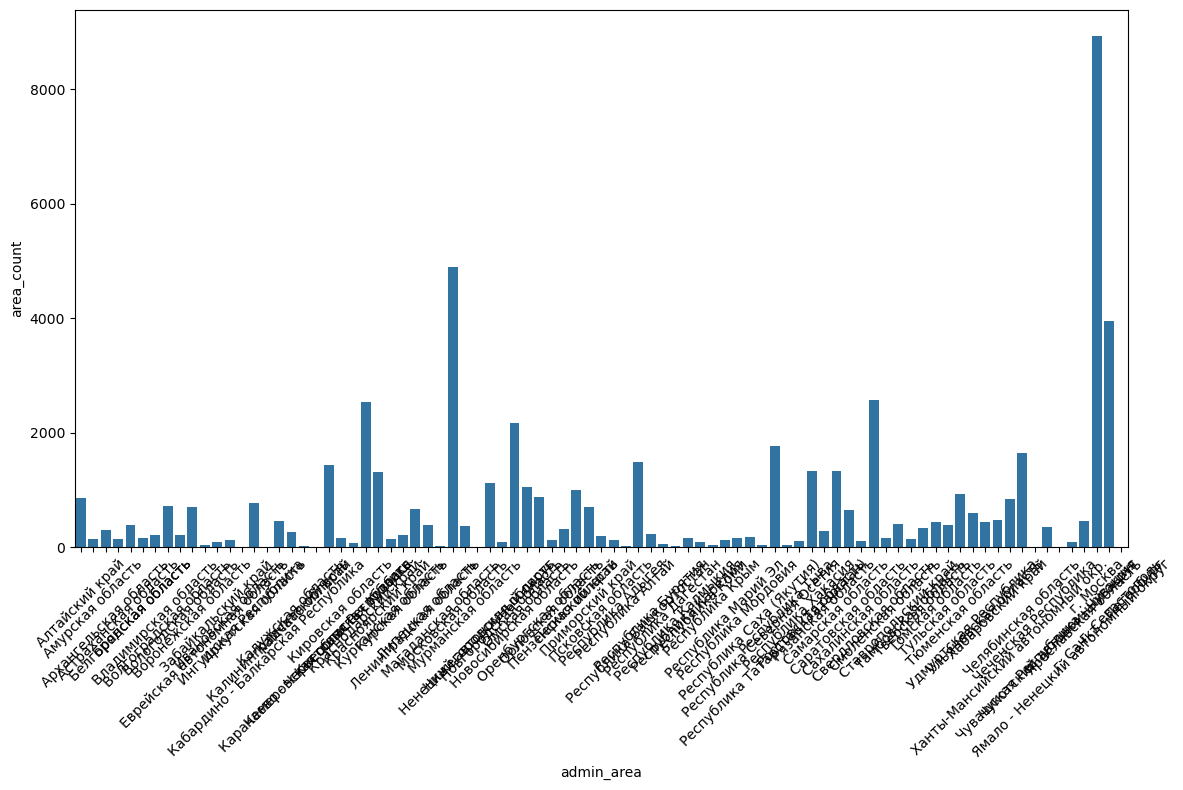

In [78]:
plt.figure(figsize=(12,8))
sns.barplot(df_visuzlize_cat_admin, x="admin_area", y="area_count")
# Rotate x-axis labels by 45 degrees
plt.xticks(rotation=45)
# Add padding so labels don't get cut off
plt.tight_layout()
plt.show()

In [92]:
df_train_3_cat.isnull().sum()/len(df_train_3_cat)

adminarea          0.254773
city_smart_name    0.123239
addrref            0.111335
gender             0.000000
dtype: float64

In [79]:
df_train_3_nums.head()

,by_category__amount__sum__eoperation_type_name__perevod_po_nomeru_telefona,avg_by_category__amount__sum__cashflowcategory_name__elektronnye_dengi,transaction_category_supermarket_sum_cnt_m3_4,avg_by_category__amount__sum__cashflowcategory_name__vydacha_nalichnyh_v_bankomate,hdb_bki_active_pil_max_limit,transaction_category_supermarket_percent_cnt_2m,transaction_category_supermarket_inc_cnt_2m,transaction_category_supermarket_sum_cnt_m2,avg_by_category__amount__sum__cashflowcategory_name__gipermarkety,avg_by_category__amount__sum__cashflowcategory_name__kafe,...,curbal_usd_amt_cm_avg,profit_income_out_rur_amt_l2m,accountsalary_out_flag,blacklist_flag,profit_income_out_rur_amt_12m,profit_income_out_rur_amt_9m,nonresident_flag,age,target,w
0,364.931507,NaN,29.0,3690.410959,NaN,0.514286,0.964758,36.0,9506.734521,2007.123288,...,0.0,123.0,1.0,0.0,118.000000,17.888889,0.0,40.0,109324.476325,0.301217
1,NaN,3237.105047,2.0,8328.075710,260200.0,0.545455,1.761111,12.0,725.135016,3813.028391,...,77.0,2709.0,1.0,0.0,5678.090909,6939.888889,0.0,43.0,25558.028662,0.695800
2,NaN,NaN,41.0,2161.643836,NaN,0.777778,2.027778,77.0,54.825205,1201.316712,...,85.0,109.0,1.0,0.0,120.833333,115.777778,0.0,48.0,40666.753098,0.515970
3,324.450867,346.820809,58.0,NaN,NaN,0.777778,0.996708,56.0,1748.765896,2031.156069,...,0.0,414.0,1.0,0.0,189.166667,189.166667,0.0,47.0,43856.672058,0.478003
4,11338.273973,33.369863,22.0,NaN,1000000.0,0.591837,1.269185,29.0,5784.880274,376.438356,...,0.0,795.0,1.0,0.0,406.833333,551.000000,0.0,46.0,130420.851992,0.552314


### Fill in missing values numerical features

In [169]:
(df_train_3_nums.isnull().sum()/len(df_train_3_nums)).head()

by_category__amount__sum__eoperation_type_name__perevod_po_nomeru_telefona            0.496588
avg_by_category__amount__sum__cashflowcategory_name__elektronnye_dengi                0.483330
transaction_category_supermarket_sum_cnt_m3_4                                         0.475074
avg_by_category__amount__sum__cashflowcategory_name__vydacha_nalichnyh_v_bankomate    0.454497
hdb_bki_active_pil_max_limit                                                          0.454158
dtype: float64

In [170]:
df_train_3_nums_filled = df_train_3_nums.copy()

In [171]:
(df_train_3_nums_filled.isnull().sum()/len(df_train_3_nums_filled)).head()

by_category__amount__sum__eoperation_type_name__perevod_po_nomeru_telefona            0.496588
avg_by_category__amount__sum__cashflowcategory_name__elektronnye_dengi                0.483330
transaction_category_supermarket_sum_cnt_m3_4                                         0.475074
avg_by_category__amount__sum__cashflowcategory_name__vydacha_nalichnyh_v_bankomate    0.454497
hdb_bki_active_pil_max_limit                                                          0.454158
dtype: float64

In [173]:
from sklearn.impute import SimpleImputer, KNNImputer
def test_imputation_strategies(X):
    # imputer = SimpleImputer(strategy=strategy)
    imputer = KNNImputer(n_neighbors=5)
    numeric_cols = X.columns
    X[numeric_cols] = imputer.fit_transform(X[numeric_cols])
    return X

In [174]:
df_train_3_nums_filled = test_imputation_strategies(df_train_3_nums_filled)

In [181]:
## confirm if mssing data are already filled
(df_train_3_nums_filled.isnull().sum()/len(df_train_3_nums_filled)).head()

by_category__amount__sum__eoperation_type_name__perevod_po_nomeru_telefona            0.0
avg_by_category__amount__sum__cashflowcategory_name__elektronnye_dengi                0.0
transaction_category_supermarket_sum_cnt_m3_4                                         0.0
avg_by_category__amount__sum__cashflowcategory_name__vydacha_nalichnyh_v_bankomate    0.0
hdb_bki_active_pil_max_limit                                                          0.0
dtype: float64

In [176]:
# There currently have 135 Numerical features, and They neeed to be reduced

In [ ]:
## method 1: quick correlation check

In [114]:
## find highly correlated pairs

In [130]:
# corr_matrix_numerical = df_train_3_nums_filled.corr()
# corr_matrix_numerical.head()
# target_correlation = corr_matrix_numerical["target"]
# target_correlation.abs().sort_values(ascending=False)

# def find_highly_correlated_features(corr_matrix, threshold=0.85):
#     upper_tri = corr_matrix.where(
#         np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
#     )
    
#     # Find features with correlation > threshold
#     to_drop = set()
#     for col in upper_tri.columns:
#         correlated_features = upper_tri[col][abs(upper_tri[col]) > threshold].index.tolist()
#         for feature in correlated_features:
#             if feature not in to_drop:
#                 # Drop the feature that appears later in correlation analysis
#                 to_drop.add(col)
#                 break
    
#     return list(to_drop)

# high_corr_threshold = 0.85 
# features_to_drop = find_highly_correlated_features(corr_matrix_numerical, high_corr_threshold)

In [182]:
def reduce_dimensionality(X,y):
    ## Step1: remove feature with very low variance - 0.01
    variances = X.var()
    feature_to_remove = variances[variances < 0.01].index.tolist()
    X_temp = X.drop(columns=feature_to_remove)
    print(f"Step 1: Removed {len(feature_to_remove)} constant features")

    ## Step2: Remove data features with very high correlation
    feature_corr_matrix = X.corr()
    upper_tri = feature_corr_matrix.where(np.triu(np.ones(feature_corr_matrix.shape), k=1).astype(bool))

    to_drop = set()
    for col in upper_tri.columns:
        correlated = upper_tri[col][abs(upper_tri[col]) > 0.85].index.tolist()
        for feature in correlated:
            if feature not in to_drop:
                to_drop.add(col)
                break
    X_temp = X_temp.drop(columns=list(to_drop))
    print(f"Step 2: Removed {len(to_drop)} highly correlated features")

    ##Step 3: Get feature importance from XGBoost
    from sklearn.model_selection import train_test_split
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y, test_size=0.2, random_state=42
    )
    
    model = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    
    importance_df = pd.DataFrame({
        'feature': X_temp.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    importance_df['cumulative'] = importance_df['importance'].cumsum()
    important_features = importance_df[importance_df['cumulative'] <= 0.95]['feature'].tolist()
    print(f"Step 3: Keeping {len(important_features)} important features (95% of total importance)")
    print(f"Total reduction: {X.shape[1]} → {len(important_features)} features")

    return X[important_features]
    

In [183]:
X_temp = df_train_3_nums_filled.copy()
X_temp = X_temp.drop(columns=["target"])
X_reduced = reduce_dimensionality(X_temp,df_train_3_nums_filled["target"])

Step 1: Removed 3 constant features
Step 2: Removed 26 highly correlated features
Step 3: Keeping 80 important features (95% of total importance)
Total reduction: 134 → 80 features


## Training Round 2 WITH XGBBOOST:

In [189]:
def train_and_predict(X,y):
    from sklearn.model_selection import train_test_split
    import xgboost as xgb
    from sklearn.metrics import mean_squared_error
    from sklearn.metrics import r2_score
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2,      
        random_state=42,    
        shuffle=True 
    )
    
    w_test = X_test["w"]
    X_train = X_train.drop(columns=["w"])
    X_test = X_test.drop(columns=["w"])
    
    model = xgb.XGBRegressor(enable_categorical=True,
                             n_estimators=1000, 
                             max_depth=7, 
                             eta=0.1, 
                             subsample=0.7, 
                             olsample_bytree=0.8)
    
    print("Training XGBoost Regressor...")
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=100              
    )
    print("Finished Training XGBoost Regressor...")
    # Make predictions
    print("Started_Inderence...")
    y_pred_xg = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred_xg)
    r2 = r2_score(y_test, y_pred_xg)
    print(f"Regression Results:")
    print(f"MSE: {mse:.4f}")
    print(f"R² Score: {r2:.4f}")
    WMAE = weighted_mean_absolute_error(y_test.values, y_pred_xg,  w_test)
    print(f"WMAE = {WMAE:.2f}")
    return model, mse, r2, WMAE

### Training with filled numerical features + default categorical features

In [190]:
## with filled numerical features + default categorical features
combined_data_2 = pd.concat([X_reduced, df_train_3_cat], axis=1)
model_xg_filled, MSE_2, r2_2, WMAE_2 = train_and_predict(combined_data_2, df_train_3_nums_filled["target"])

Training XGBoost Regressor...
[0]	validation_0-rmse:110669.49536


C:\Users\emryz\anaconda3\envs\torch\lib\site-packages\xgboost\core.py:158: UserWarning: [21:52:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "olsample_bytree" } are not used.

  warnings.warn(smsg, UserWarning)


[100]	validation_0-rmse:73745.45555
[200]	validation_0-rmse:72938.50214
[300]	validation_0-rmse:72665.64249
[400]	validation_0-rmse:72595.33183
[500]	validation_0-rmse:72502.55886
[600]	validation_0-rmse:72520.65347
[700]	validation_0-rmse:72500.08552
[800]	validation_0-rmse:72463.35134
[900]	validation_0-rmse:72459.18148
[999]	validation_0-rmse:72468.33868
Finished Training XGBoost Regressor...
Started_Inderence...
Regression Results:
MSE: 5251660118.0259
R² Score: 0.6081
WMAE = 39451.88


### Training using missing Data (numerical features) but with features of only important data

In [194]:
combined_first_dataset.isnull().sum().head()

adminarea                                                                     19563
city_smart_name                                                                9463
addrref                                                                        8549
gender                                                                            0
by_category__amount__sum__eoperation_type_name__perevod_po_nomeru_telefona    38131
dtype: int64

In [195]:
X = combined_first_dataset.copy() ## From the first dataset without processing
X = X.drop(columns=["target"]) ## From the first dataset without processing

In [198]:
## with not filled numerical features + default categorical features
combined_data_3 = pd.concat([X[X_reduced.columns.tolist()], df_train_3_cat], axis=1)
model_combined_missing, MSE_3, r2_3, WMAE_3 = train_and_predict(combined_data_3, df_train_3_nums_filled["target"])

Training XGBoost Regressor...
[0]	validation_0-rmse:111151.99359


C:\Users\emryz\anaconda3\envs\torch\lib\site-packages\xgboost\core.py:158: UserWarning: [22:00:03] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "olsample_bytree" } are not used.

  warnings.warn(smsg, UserWarning)


[100]	validation_0-rmse:81552.26515
[200]	validation_0-rmse:81290.17967
[300]	validation_0-rmse:81412.91080
[400]	validation_0-rmse:81523.72861
[500]	validation_0-rmse:81605.29532
[600]	validation_0-rmse:81698.17736
[700]	validation_0-rmse:81772.91936
[800]	validation_0-rmse:81839.73257
[900]	validation_0-rmse:81923.70908
[999]	validation_0-rmse:82022.45279
Finished Training XGBoost Regressor...
Started_Inderence...
Regression Results:
MSE: 6727692814.4924
R² Score: 0.4979
WMAE = 46984.04


## Working on Categorical Features

In [200]:
df_train_3_cat_filled = df_train_3_cat.copy()

In [201]:
df_train_3_cat_filled.isnull().sum() / len(df_train_3_cat_filled) * 100

adminarea          25.477301
city_smart_name    12.323861
addrref            11.133540
gender              0.000000
dtype: float64

In [202]:
## Check cardinaly of each category
for cat in df_train_3_cat_filled.columns:
    print(f"{cat} - {df_train_3_cat_filled[cat].nunique()}")

adminarea - 85
city_smart_name - 105
addrref - 62
gender - 2


In [203]:
## For the tree algorithms
def tree_based_algorithm(X_cat):
    X_encoded = X_cat.copy()

    for col in X_encoded.columns.tolist():
        X_encoded[col] = X_encoded[col].astype("category")

    for col in ['city_smart_name', 'adminarea']:
        freq = X[col].value_counts(normalize=True)
        X_encoded[f'{col}_freq'] = X[col].map(freq)

    return X_encoded
        
    

In [204]:
ans = tree_based_algorithm(df_train_3_cat_filled)

In [205]:
df_train_3_cat_filled = ans[["addrref","gender","city_smart_name_freq","adminarea_freq"]]

In [279]:
df_train_3_cat_filled.head()

,addrref,gender,city_smart_name_freq,adminarea_freq
0,Свердловская область,Женский,0.036228,0.044947
1,Краснодарский край,Женский,0.026529,0.044440
2,Томская область,Женский,0.007531,0.037852
3,Хабаровский край,Мужской,0.006343,0.008388
4,Новосибирская область,Женский,0.020290,0.037852


### Training with not filled numerical features + encoded category

In [206]:
combined_data_4 = pd.concat([combined_first_dataset[X_reduced.columns.tolist()], df_train_3_cat_filled], axis=1)
model_encoded_cat_notfilled_num,MSE_4, r2_4, WMAE_4 = train_and_predict(combined_data_4, df_train_3_nums_filled["target"])

Training XGBoost Regressor...
[0]	validation_0-rmse:111219.17656


C:\Users\emryz\anaconda3\envs\torch\lib\site-packages\xgboost\core.py:158: UserWarning: [22:06:43] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "olsample_bytree" } are not used.

  warnings.warn(smsg, UserWarning)


[100]	validation_0-rmse:80598.23737
[200]	validation_0-rmse:80522.47059
[300]	validation_0-rmse:80616.21010
[400]	validation_0-rmse:80689.70468
[500]	validation_0-rmse:80763.14550
[600]	validation_0-rmse:80870.10745
[700]	validation_0-rmse:80910.47232
[800]	validation_0-rmse:80980.60375
[900]	validation_0-rmse:81132.82105
[999]	validation_0-rmse:81234.44641
Finished Training XGBoost Regressor...
Started_Inderence...
Regression Results:
MSE: 6599035286.4795
R² Score: 0.5075
WMAE = 46362.96


### Training with filled numerical features + encoded category

In [208]:
combined_data_5 = pd.concat([X_reduced, df_train_3_cat_filled], axis=1)
model_xg_filled_encoded_cat, MSE_5, r2_5, WMAE_5 = train_and_predict(combined_data_5, df_train_3_nums_filled["target"])

Training XGBoost Regressor...
[0]	validation_0-rmse:110449.41813


C:\Users\emryz\anaconda3\envs\torch\lib\site-packages\xgboost\core.py:158: UserWarning: [22:09:05] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "olsample_bytree" } are not used.

  warnings.warn(smsg, UserWarning)


[100]	validation_0-rmse:71977.34893
[200]	validation_0-rmse:70956.62975
[300]	validation_0-rmse:70656.16130
[400]	validation_0-rmse:70521.12651
[500]	validation_0-rmse:70400.93678
[600]	validation_0-rmse:70355.06154
[700]	validation_0-rmse:70324.11702
[800]	validation_0-rmse:70316.02281
[900]	validation_0-rmse:70301.18314
[999]	validation_0-rmse:70311.89787
Finished Training XGBoost Regressor...
Started_Inderence...
Regression Results:
MSE: 4943762995.9187
R² Score: 0.6310
WMAE = 37902.80


## CAT BOOST Algorithm

In [212]:
def train_and_predict_catboost(X, y):
    from sklearn.model_selection import train_test_split
    import catboost as cb
    from sklearn.metrics import mean_squared_error, r2_score
    import numpy as np
    
    # 1. Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2,      
        random_state=42,    
        shuffle=True 
    )
    
    # 2. Handle 'w' column
    w_test = X_test["w"]
    X_train = X_train.drop(columns=["w"])
    X_test = X_test.drop(columns=["w"])
    
    # 3. Prepare categorical features for CatBoost
    categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Convert to string (CatBoost requirement)
    for col in categorical_cols:
        X_train[col] = X_train[col].astype(str).fillna('MISSING')
        X_test[col] = X_test[col].astype(str).fillna('MISSING')
    
    # 4. Create CatBoost model (parameters matched to your XGBoost)
  #     subsample: 0.8
  # random_strength: 2 ##
  # min_data_in_leaf: 5 ##
  # max_bin: 512 ##
  # learning_rate: 0.05
  # l2_leaf_reg: 3 ##
  # iterations: 2000
  # grow_policy: SymmetricTree ##
  # depth: 8 
  # colsample_bylevel: 0.7
  # boosting_type: Plain ##
  # bagging_temperature: 0.5 ##

        ## With previous iterations
    # model = cb.CatBoostRegressor(
    #     iterations=2000,           # n_estimators=1000
    #     depth=8,                   # max_depth=7
    #     learning_rate=0.05,         # eta=0.1
    #     subsample=0.8,             # subsample=0.7
    #     colsample_bylevel=0.7,     # colsample_bytree=0.8
    #     random_seed=42,            # random_state=42
    #     cat_features=categorical_cols,
    #     verbose=100,
    #     early_stopping_rounds=50,
    #     thread_count=-1,
    #     random_strength=2, 
    #     min_data_in_leaf=5,
    #     max_bin=512,
    #     l2_leaf_reg=3,
    #     grow_policy="SymmetricTree",
    #     boosting_type="Plain",
    #     bagging_temperature=0.5
    # )

    model = cb.CatBoostRegressor(
      subsample=0.8,
      random_strength=2, ##
      min_data_in_leaf=5, ##
      max_bin=512, ##
      learning_rate=0.05,
      l2_leaf_reg=3, ##
      iterations=2000,
      grow_policy="SymmetricTree", ##
      depth=8 ,
      colsample_bylevel=0.7,
      boosting_type="Plain", ##
      bagging_temperature=0.5, ##
      cat_features=categorical_cols,
    )
    
    
    print("Training CatBoost Regressor...")
    
    # 5. Train with evaluation set
    model.fit(
        X_train, y_train,
        eval_set=(X_test, y_test),
        verbose=100
    )
    
    print("Finished Training CatBoost Regressor...")
    
    # 6. Predict and evaluate
    print("Started Inference...")
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"Regression Results:")
    print(f"MSE: {mse:.4f}")
    print(f"R² Score: {r2:.4f}")
    
    WMAE = weighted_mean_absolute_error(y_test.values, y_pred, w_test)
    print(f"WMAE = {WMAE:.2f}")
    
    return model,mse, r2, WMAE

### Training with filled numerical features + default categorical features

In [213]:
combined_data_cat_1 = pd.concat([X_reduced, df_train_3_cat], axis=1)
model_cat_full, MSE_cat_1, r2_cat_1, WMAE_cat_1 = train_and_predict_catboost(combined_data_cat_1, df_train_3_nums_filled["target"])

Training CatBoost Regressor...
0:	learn: 109296.1536963	test: 113571.4243128	best: 113571.4243128 (0)	total: 287ms	remaining: 9m 33s
100:	learn: 65685.0172800	test: 76827.3381156	best: 76827.3381156 (100)	total: 13.8s	remaining: 4m 19s
200:	learn: 59755.2397144	test: 73976.7572480	best: 73976.7572480 (200)	total: 27.4s	remaining: 4m 5s
300:	learn: 55021.4845763	test: 72647.9527484	best: 72647.9527484 (300)	total: 40.9s	remaining: 3m 51s
400:	learn: 51329.8890625	test: 71766.2203033	best: 71766.2203033 (400)	total: 54.3s	remaining: 3m 36s
500:	learn: 48464.7126650	test: 71051.5688784	best: 71051.5688784 (500)	total: 1m 7s	remaining: 3m 22s
600:	learn: 46085.2973175	test: 70677.3090373	best: 70677.3090373 (600)	total: 1m 21s	remaining: 3m 9s
700:	learn: 44131.9201496	test: 70396.4809849	best: 70396.4809849 (700)	total: 1m 35s	remaining: 2m 56s
800:	learn: 42404.8617177	test: 70054.2220638	best: 70054.2220638 (800)	total: 1m 48s	remaining: 2m 42s
900:	learn: 40894.7609396	test: 69821.4143

In [215]:
### Training with not filled missing value numerical features + default categorical features (## BAD)

In [216]:
combined_data_cat_2 = pd.concat([combined_first_dataset[X_reduced.columns.tolist()], df_train_3_cat], axis=1)
model_missing_numerical, MSE_cat_2, r2_cat_2, WMAE_cat_2 = train_and_predict_catboost(combined_data_cat_2, df_train_3_nums_filled["target"])

Training CatBoost Regressor...
0:	learn: 109400.8926365	test: 113737.0876601	best: 113737.0876601 (0)	total: 107ms	remaining: 3m 34s
100:	learn: 71337.4793034	test: 82928.2531978	best: 82928.2531978 (100)	total: 13.7s	remaining: 4m 16s
200:	learn: 66501.3575615	test: 81498.9592001	best: 81498.9592001 (200)	total: 27.7s	remaining: 4m 7s
300:	learn: 62718.7569585	test: 80757.6938747	best: 80756.9824849 (298)	total: 40.9s	remaining: 3m 51s
400:	learn: 59812.6809671	test: 80286.7181109	best: 80286.7181109 (400)	total: 54.3s	remaining: 3m 36s
500:	learn: 57454.1150465	test: 79997.6521656	best: 79993.4945888 (496)	total: 1m 7s	remaining: 3m 23s
600:	learn: 55433.4745573	test: 79822.1493994	best: 79820.5150240 (599)	total: 1m 23s	remaining: 3m 13s
700:	learn: 53818.9314593	test: 79619.2513346	best: 79619.2513346 (700)	total: 1m 37s	remaining: 3m
800:	learn: 52423.0891466	test: 79507.2840680	best: 79498.1369298 (788)	total: 1m 51s	remaining: 2m 46s
900:	learn: 51243.0155850	test: 79448.9515988

In [ ]:
### Training with  filled numerical features + encoded category

In [218]:
combined_data_cat_3 = pd.concat([X_reduced, df_train_3_cat_filled], axis=1)
cat_model_final, MSE_cat_3, r2_cat_3, WMAE_cat_3 = train_and_predict_catboost(combined_data_cat_3, df_train_3_nums_filled["target"])

Training CatBoost Regressor...
0:	learn: 109218.8429262	test: 113561.0494352	best: 113561.0494352 (0)	total: 97.4ms	remaining: 3m 14s
100:	learn: 65666.8363850	test: 76784.1174754	best: 76784.1174754 (100)	total: 11.3s	remaining: 3m 31s
200:	learn: 59570.8517706	test: 74185.8720820	best: 74185.8720820 (200)	total: 22.5s	remaining: 3m 21s
300:	learn: 55062.0064609	test: 72551.2565330	best: 72551.2565330 (300)	total: 34.4s	remaining: 3m 13s
400:	learn: 51338.3339281	test: 71685.7625989	best: 71679.1282933 (398)	total: 46.1s	remaining: 3m 3s
500:	learn: 48482.1468231	test: 71001.1052682	best: 70990.1469599 (496)	total: 58s	remaining: 2m 53s
600:	learn: 46083.5563046	test: 70551.9889661	best: 70551.9889661 (600)	total: 1m 9s	remaining: 2m 42s
700:	learn: 44029.3588698	test: 70107.8521648	best: 70107.8521648 (700)	total: 1m 21s	remaining: 2m 31s
800:	learn: 42287.0619347	test: 69874.7634895	best: 69874.7634895 (800)	total: 1m 33s	remaining: 2m 20s
900:	learn: 40690.6449718	test: 69579.27889

## Saving best model

In [220]:
import joblib
import json

In [221]:
MODEL_PATH = 'prototype_cat.joblib'
FEATURES_PATH = 'model_features_cat.json'
joblib.dump(cat_model_final, MODEL_PATH)

['prototype_cat.joblib']

In [ ]:
# X_reduced.columns.tolist()

In [222]:
with open(FEATURES_PATH, 'w') as f:
    json.dump(X_reduced.columns.to_list(), f)

## Summary of models and results

In [226]:
model_results = pd.DataFrame({
    "model_name":["cat_model_final","model_missing_numerical","model_cat_full",
                  "model_xg_filled_encoded_cat",
                  "model_encoded_cat_notfilled_num","model_combined_missing","model_xg_filled"],
    "MSE":[4641102477.6545, 6221519422.7156, 4684569918.2583,4943762995.9187,6599035286.4795, 6727692814.4924, 5251660118.0259 ],
    "R^2 Score":[0.6536,0.5357, 0.6504, 0.6310, 0.5075, 0.4979, 0.6081],
    "WMAE":[37191.05, 45124.08, 37435.42, 37902.80, 46362.96, 46984.04, 39451.88]
}).sort_values(by="WMAE",ascending=True)

In [227]:
model_results

,model_name,MSE,R^2 Score,WMAE
0,cat_model_final,4.641102e+09,0.6536,37191.05
2,model_cat_full,4.684570e+09,0.6504,37435.42
3,model_xg_filled_encoded_cat,4.943763e+09,0.6310,37902.80
6,model_xg_filled,5.251660e+09,0.6081,39451.88
1,model_missing_numerical,6.221519e+09,0.5357,45124.08
4,model_encoded_cat_notfilled_num,6.599035e+09,0.5075,46362.96
5,model_combined_missing,6.727693e+09,0.4979,46984.04


## Parameter tuning with catboost

In [294]:
def catboost_hyperparameter_tuning(X, y, cv_folds=5, n_iter=20):
    """
    Hyperparameter tuning for CatBoost using RandomizedSearchCV
    """
    import catboost as cb
    from sklearn.model_selection import RandomizedSearchCV, KFold
    from sklearn.metrics import make_scorer, mean_squared_error
    import numpy as np
    import pandas as pd
    
    print("Starting CatBoost Hyperparameter Tuning...")
    
    # Prepare categorical features
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    X_tune = X.copy()
    
    for col in categorical_cols:
        X_tune[col] = X_tune[col].astype(str).fillna('MISSING')
    
    # Define parameter grid
    param_dist = {
        'iterations': [500, 1000, 1500, 2000],
        'depth': [4, 6, 8, 10, 12],
        'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15],
        'l2_leaf_reg': [1, 3, 5, 7, 9],
        # 'border_count': [32, 64, 128, 254],
        'random_strength': [0.5, 1, 2, 3],
        'bagging_temperature': [0, 0.5, 1, 2],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bylevel': [0.6, 0.7, 0.8, 0.9, 1.0],
        'min_data_in_leaf': [1, 3, 5, 10, 20],
        'max_bin': [128, 254, 512],
        'grow_policy': ['SymmetricTree', 'Depthwise', 'Lossguide'],
        'boosting_type': ['Ordered', 'Plain']
    }
    
    # Create CatBoost model
    cat_model = cb.CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        verbose=0,  # Silent during tuning
        cat_features=categorical_cols,
        thread_count=-1
    )
    
    # Create KFold cross-validator
    kfold = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    # Define scoring (negative RMSE since sklearn maximizes)
    scorer = make_scorer(lambda y_true, y_pred: -np.sqrt(mean_squared_error(y_true, y_pred)))
    
    # Randomized search
    random_search = RandomizedSearchCV(
        estimator=cat_model,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=scorer,
        cv=kfold,
        verbose=3,
        random_state=42,
        n_jobs=1,  # CatBoost uses all cores internally
        return_train_score=True
    )
    
    print(f"Running RandomizedSearchCV with {n_iter} iterations and {cv_folds}-fold CV...")
    
    # Fit the random search
    random_search.fit(X_tune, y)
    
    print("\n" + "="*60)
    print("HYPERPARAMETER TUNING RESULTS")
    print("="*60)
    
    # Best parameters
    print(f"\nBest Parameters:")
    for param, value in random_search.best_params_.items():
        print(f"  {param}: {value}")
    
    # Best score (convert back from negative RMSE)
    best_rmse = -random_search.best_score_
    print(f"\nBest Cross-Validation RMSE: {best_rmse:.4f}")
    
    # Results DataFrame
    results_df = pd.DataFrame(random_search.cv_results_)
    results_df = results_df.sort_values('mean_test_score', ascending=False)
    
    # Top 5 parameter combinations
    print(f"\nTop 5 Parameter Combinations:")
    for i in range(min(5, len(results_df))):
        print(f"\n#{i+1} RMSE: {-results_df.iloc[i]['mean_test_score']:.4f}")
        top_params = results_df.iloc[i]['params']
        for param in ['iterations', 'depth', 'learning_rate', 'l2_leaf_reg']:
            if param in top_params:
                print(f"  {param}: {top_params[param]}")
    
    return random_search, results_df

In [295]:
combined_data_cat_3 = pd.concat([combined_first_dataset[X_reduced.columns.tolist()], df_train_3_cat_filled], axis=1)
MSE_cat_3, r2_cat_3, WMAE_cat_3 = catboost_hyperparameter_tuning(combined_data_cat_3, df_train_3_nums_filled["target"])

Starting CatBoost Hyperparameter Tuning...
Running RandomizedSearchCV with 20 iterations and 5-fold CV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END bagging_temperature=2, boosting_type=Plain, colsample_bylevel=0.6, depth=10, grow_policy=Lossguide, iterations=1000, l2_leaf_reg=9, learning_rate=0.1, max_bin=128, min_data_in_leaf=10, random_strength=3, subsample=0.9;, score=(train=-19746.042, test=-52071.742) total time= 4.6min
[CV 2/5] END bagging_temperature=2, boosting_type=Plain, colsample_bylevel=0.6, depth=10, grow_policy=Lossguide, iterations=1000, l2_leaf_reg=9, learning_rate=0.1, max_bin=128, min_data_in_leaf=10, random_strength=3, subsample=0.9;, score=(train=-20341.774, test=-45069.520) total time= 4.3min
[CV 3/5] END bagging_temperature=2, boosting_type=Plain, colsample_bylevel=0.6, depth=10, grow_policy=Lossguide, iterations=1000, l2_leaf_reg=9, learning_rate=0.1, max_bin=128, min_data_in_leaf=10, random_strength=3, subsample=0.9;, score=(trai

C:\Users\emryz\anaconda3\envs\torch\lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
45 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
45 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\emryz\anaconda3\envs\torch\lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\emryz\anaconda3\envs\torch\lib\site-packages\catboost\core.py", line 5873, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline,
  File "C:\Users\emryz\anaconda3\envs\torch\lib\si


HYPERPARAMETER TUNING RESULTS

Best Parameters:
  subsample: 0.8
  random_strength: 2
  min_data_in_leaf: 5
  max_bin: 512
  learning_rate: 0.05
  l2_leaf_reg: 3
  iterations: 2000
  grow_policy: SymmetricTree
  depth: 8
  colsample_bylevel: 0.7
  boosting_type: Plain
  bagging_temperature: 0.5

Best Cross-Validation RMSE: 47748.4736

Top 5 Parameter Combinations:

#1 RMSE: 47748.4736
  iterations: 2000
  depth: 8
  learning_rate: 0.05
  l2_leaf_reg: 3

#2 RMSE: 47956.9442
  iterations: 2000
  depth: 8
  learning_rate: 0.1
  l2_leaf_reg: 3

#3 RMSE: 48422.4337
  iterations: 1000
  depth: 10
  learning_rate: 0.1
  l2_leaf_reg: 9

#4 RMSE: 48589.5988
  iterations: 500
  depth: 8
  learning_rate: 0.15
  l2_leaf_reg: 5

#5 RMSE: 48634.9835
  iterations: 500
  depth: 8
  learning_rate: 0.03
  l2_leaf_reg: 1


ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
# Best Parameters:
#   subsample: 0.8
#   random_strength: 2
#   min_data_in_leaf: 5
#   max_bin: 512
#   learning_rate: 0.05
#   l2_leaf_reg: 3
#   iterations: 2000
#   grow_policy: SymmetricTree
#   depth: 8
#   colsample_bylevel: 0.7
#   boosting_type: Plain
#   bagging_temperature: 0.5

In [ ]:
# #1 RMSE: 47748.4736
#   iterations: 2000
#   depth: 8
#   learning_rate: 0.05
#   l2_leaf_reg: 3

# #2 RMSE: 47956.9442
#   iterations: 2000
#   depth: 8
#   learning_rate: 0.1
#   l2_leaf_reg: 3

# #3 RMSE: 48422.4337
#   iterations: 1000
#   depth: 10
#   learning_rate: 0.1
#   l2_leaf_reg: 9

# #4 RMSE: 48589.5988
#   iterations: 500
#   depth: 8
#   learning_rate: 0.15
#   l2_leaf_reg: 5

# #5 RMSE: 48634.9835
#   iterations: 500
#   depth: 8
#   learning_rate: 0.03
#   l2_leaf_reg: 1

## SHAP For interpretability

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

### Load data

In [233]:
X = combined_data_cat_3.drop(columns=["w"])
y = df_train_3_nums_filled["target"]

### Split data

In [9]:
# train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)
my_model = RandomForestClassifier(random_state=0).fit(train_X, train_y)

In [10]:
row_to_show = 5
data_for_prediction = val_X.iloc[row_to_show]

In [12]:
data_for_prediction_array = data_for_prediction.values.reshape(1, -1)

In [45]:
my_model.predict_proba(val_X.iloc[0,:].values.reshape(1, -1))

C:\Users\emryz\anaconda3\envs\torch\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([[0.62, 0.38]])

### Start interpretation

In [1]:
import shap

In [ ]:
explainer = shap.TreeExplainer(cat_model_final)

In [237]:
categorical_cols = X.select_dtypes(include=['category']).columns.tolist()

for col in categorical_cols:
    if X[col].isna().any():
        print(f"Filling NaN in {col}: {X[col].isna().sum()} NaN values")
        # Convert to string, fill NaN, then back to category
        X[col] = X[col].astype(str).fillna('MISSING').astype('category')

Filling NaN in addrref: 8549 NaN values


In [238]:
# Calculate Shap values
shap_values = explainer.shap_values(X)

In [240]:
shap_values.shape

(76786, 83)

In [243]:
explainer.expected_value

92302.99396986459

### Force plot

In [245]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X.iloc[0,:])

In [246]:
shap_values = explainer(X)

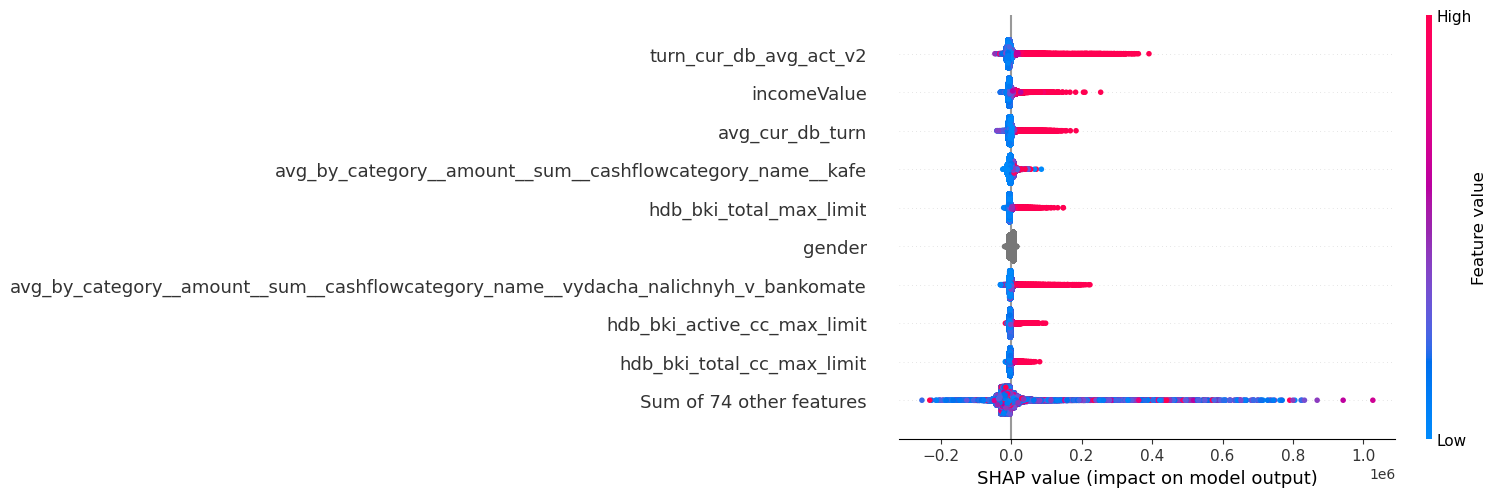

In [249]:
shap.plots.beeswarm(shap_values)

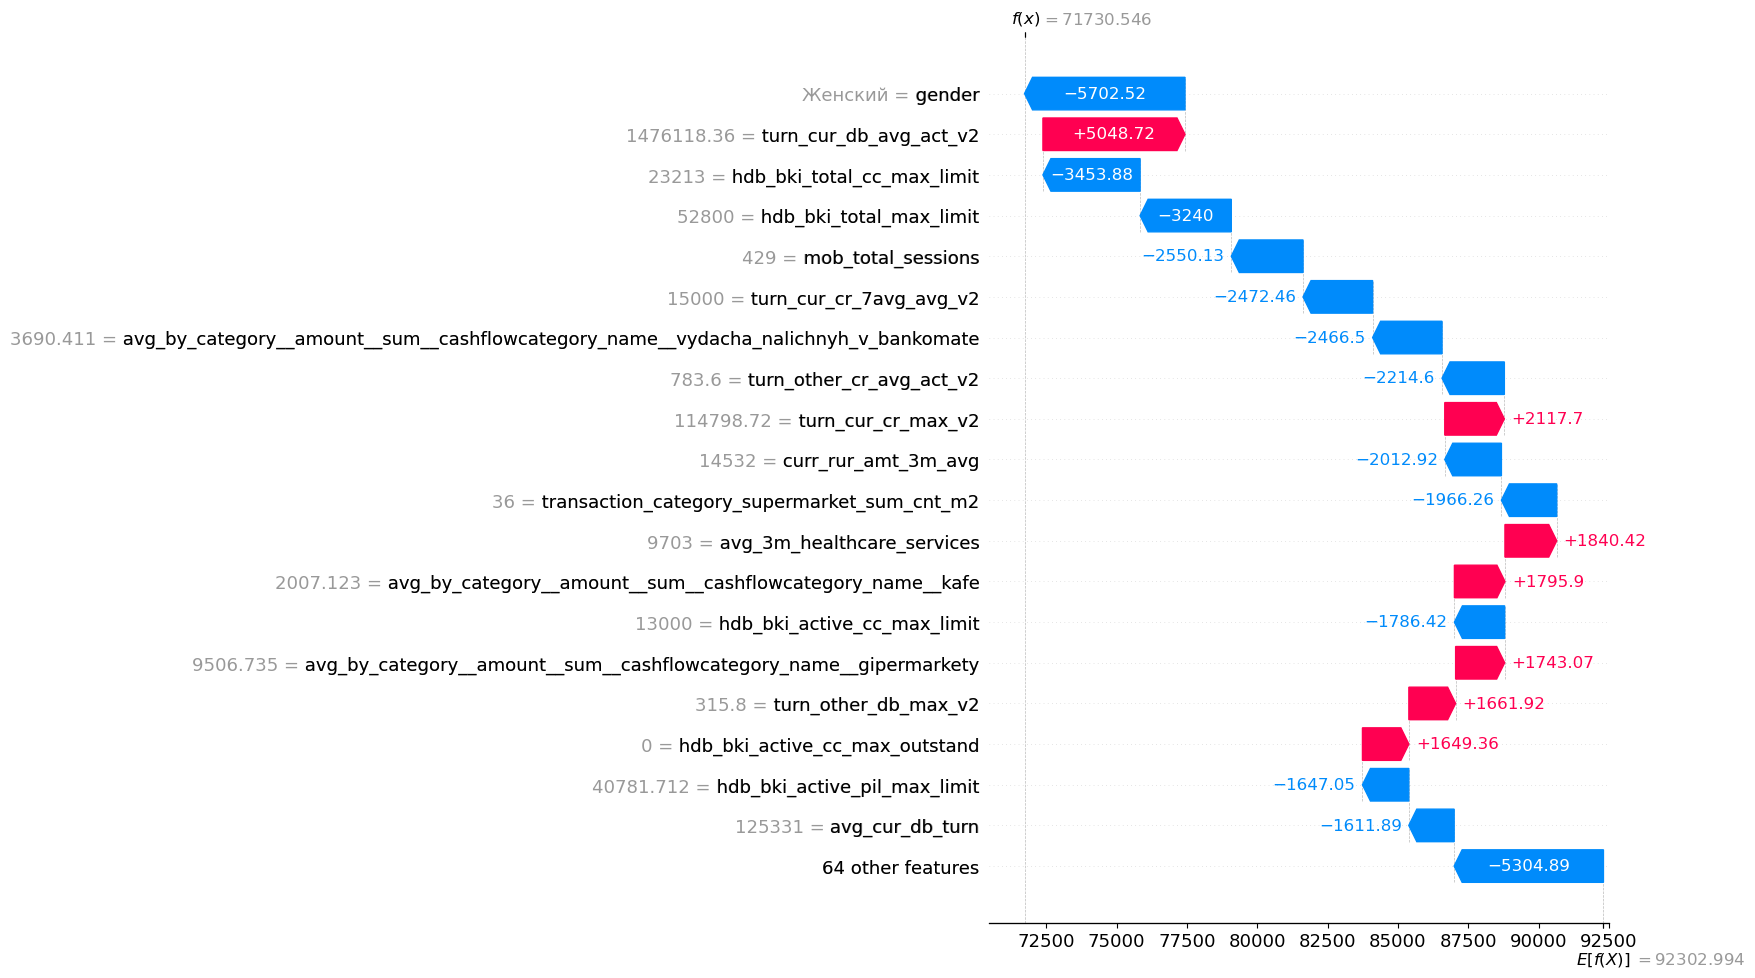

In [250]:
# shap.plots.waterfall(shap_values[0, :, 1], max_display=20)
shap.plots.waterfall(shap_values[0], max_display=20)

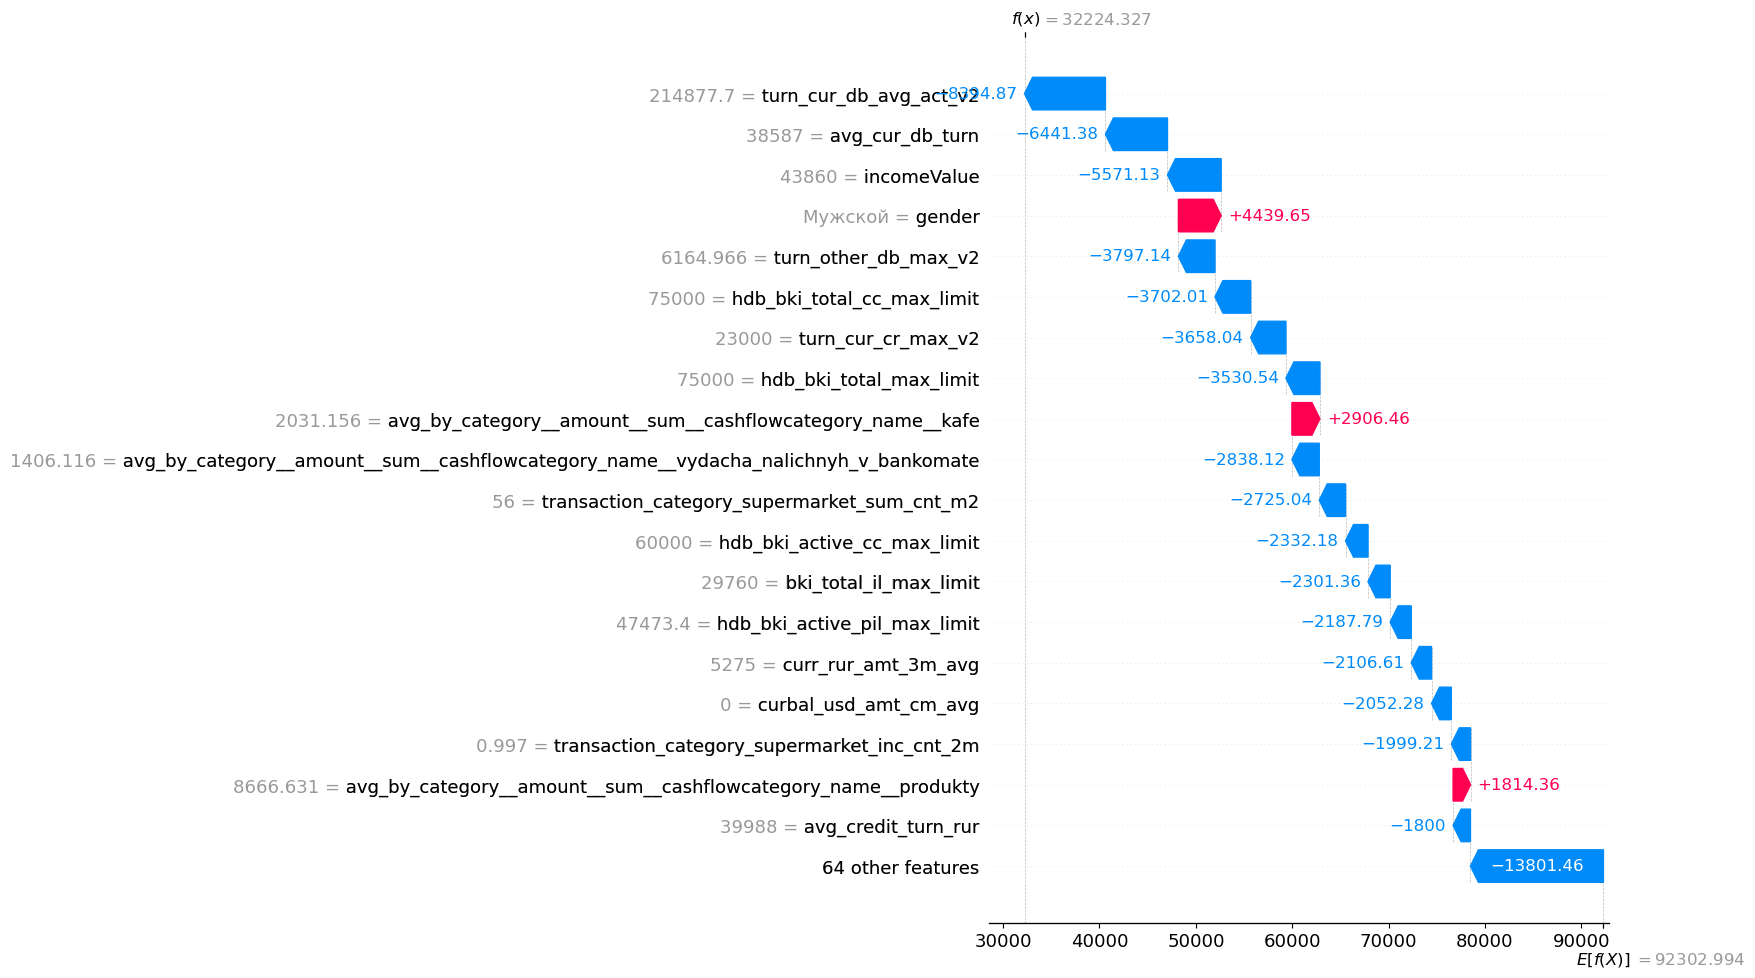

In [252]:
shap.plots.waterfall(shap_values[3], max_display=20)

In [257]:
shap.plots.force(shap_values[:100])

In [262]:
top_features = pd.DataFrame({
    'feature': X.columns,
    'impact_strength': np.abs(shap_values.values).mean(0),
    'direction': shap_values.values.mean(0)
}).sort_values('impact_strength', ascending=False)

print("Top 5 Features:")
for i, row in top_features.head(10).iterrows():
    dir_text = "INCREASES" if row['direction'] > 0 else "DECREASES"
    print(f"{row['feature']}: {dir_text} predictions (strength: {row['impact_strength']:.4f})")

Top 5 Features:
turn_cur_db_avg_act_v2: INCREASES predictions (strength: 11485.9148)
incomeValue: INCREASES predictions (strength: 7424.0713)
avg_cur_db_turn: INCREASES predictions (strength: 6492.7306)
avg_by_category__amount__sum__cashflowcategory_name__kafe: INCREASES predictions (strength: 5525.9654)
hdb_bki_total_max_limit: DECREASES predictions (strength: 5456.6721)
gender: DECREASES predictions (strength: 5425.7324)
avg_by_category__amount__sum__cashflowcategory_name__vydacha_nalichnyh_v_bankomate: DECREASES predictions (strength: 4402.1113)
hdb_bki_active_cc_max_limit: DECREASES predictions (strength: 4236.9293)
hdb_bki_total_cc_max_limit: INCREASES predictions (strength: 3846.9161)
transaction_category_supermarket_inc_cnt_2m: DECREASES predictions (strength: 3799.3967)


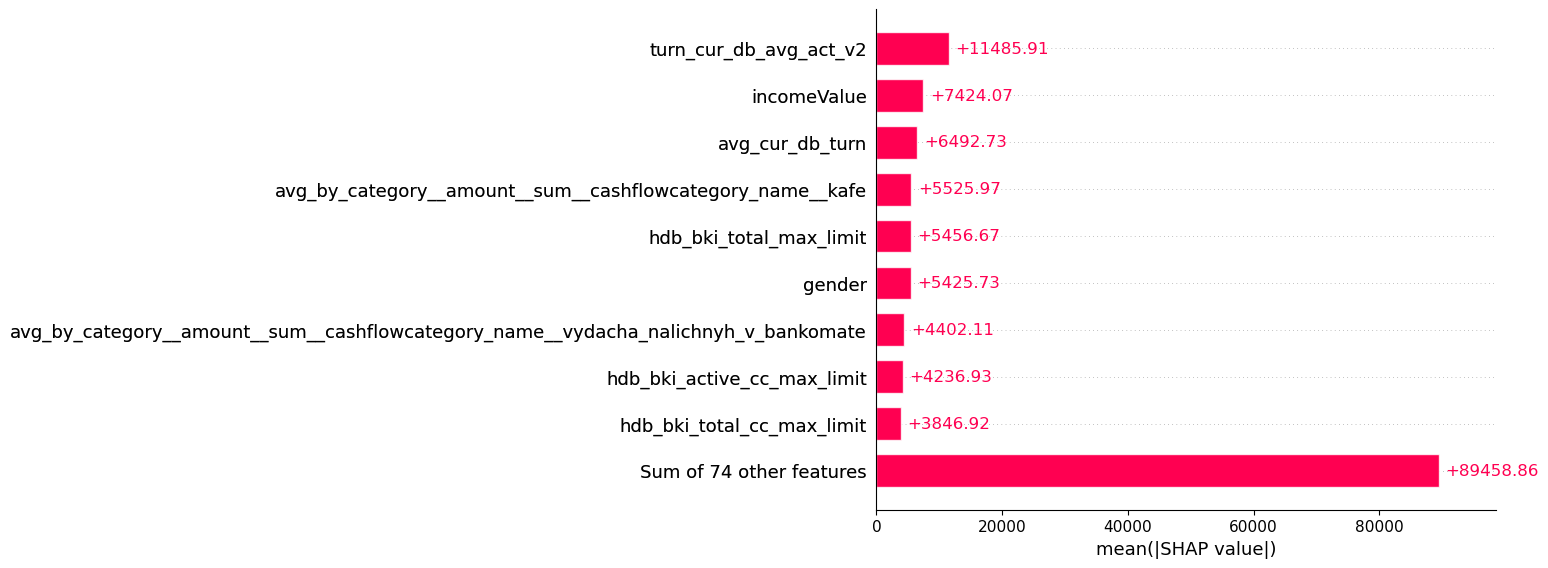

In [275]:
shap.plots.bar(shap_values, max_display=10)

### Feature description

In [264]:
feature_description = pd.read_csv("features_description.csv", delimiter=";", encoding='cp1251', index_col='признак')

In [265]:
feature_description.head()

,описание
признак,
dt,Дата актуальности признаков
target,таргет
turn_cur_cr_avg_act_v2,Средний текущий кредитовый оборот по текущим счетам за 12 месяцев
salary_6to12m_avg,Усреднённая ЗП клиента за окно в минимум 6 месяцев и максимум 12 месяцев
hdb_bki_total_max_limit,БКИ: Максимальный кредитный лимит по любому продукту за все время


In [285]:
## Description of top 10 features
for col in top_features.feature.tolist()[:10]:
   print(f"{col}: {feature_description.loc[col].values[0]}")

turn_cur_db_avg_act_v2: Средний текущий дебетовый оборот по текущим счетам за 12 месяцев
incomeValue: Значение дохода абонента
avg_cur_db_turn: Средний дебетовый оборот по текущим счетам за 3 месяца
avg_by_category__amount__sum__cashflowcategory_name__kafe: Средняя сумма транзакций в категории Кафе за месяц на протяжении года
hdb_bki_total_max_limit: БКИ: Максимальный кредитный лимит по любому продукту за все время
gender: Пол клиента
avg_by_category__amount__sum__cashflowcategory_name__vydacha_nalichnyh_v_bankomate: Средняя сумма транзакций в категории Выдача наличных в банкомате за месяц на протяжении года
hdb_bki_active_cc_max_limit: БКИ: Максимальный лимит по активному кредитному продукту Кредитная карта
hdb_bki_total_cc_max_limit: БКИ: Максимальный лимит по кредитному продукту Кредитная карта за все время
transaction_category_supermarket_inc_cnt_2m: Количество транзакций в категории Супермаркеты за последние 2 месяца поделённое на среднее Количество транзакций в этой категории за 